Block size 1: Data restored correctly.
Block size 2: Data restored correctly.
Block size 3: Data restored correctly.
Block size 4: Data restored correctly.
Block size 5: Data restored correctly.
Block size 6: Data restored correctly.
Block size 7: Data restored correctly.
Block size 8: Data restored correctly.
Block size 9: Data restored correctly.
Block size 10: Data restored correctly.
Block size 11: Data restored correctly.
Block size 12: Data restored correctly.
Block size 13: Data restored correctly.
Block size 14: Data restored correctly.
Block size 15: Data restored correctly.
Block size 16: Data restored correctly.
Block size 17: Data restored correctly.
Block size 18: Data restored correctly.
Block size 19: Data restored correctly.
Block size 20: Data restored correctly.
Block size 21: Data restored correctly.
Block size 22: Data restored correctly.
Block size 23: Data restored correctly.
Block size 24: Data restored correctly.
Block size 25: Data restored correctly.
Block siz

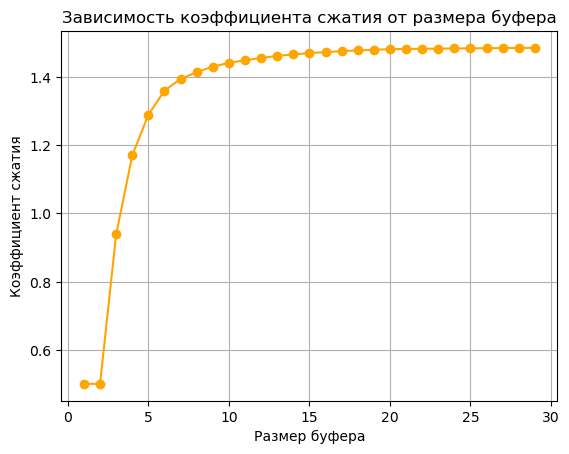

In [ ]:
import matplotlib.pyplot as plt
def lzss_encode(data: bytes, window_size: int = 1024, lookahead_size: int = 15, min_match: int = 3):
    if not data:
        return b''
    
    encoded = bytearray()
    n = len(data)
    pos = 0
    
    while pos < n:
        search_start = max(0, pos - window_size)
        search_buffer = data[search_start:pos]
        max_lookahead = min(lookahead_size, n - pos)
        
        best_offset = 0
        best_length = 0
        
        for length in range(min_match, max_lookahead + 1):
            pattern = data[pos:pos + length]
            offset = search_buffer.rfind(pattern)
            
            if offset != -1:
                actual_offset = len(search_buffer) - offset
                if actual_offset <= window_size:
                    best_offset = actual_offset
                    best_length = length
            else:
                break
        
        if best_length >= min_match:
            # Флаг 0x80 + смещение (2 байта) + длина (1 байт)
            encoded.append(0x80 | ((best_offset >> 8) & 0x7F))
            encoded.append(best_offset & 0xFF)
            encoded.append(best_length)
            pos += best_length
        else:
            # Флаг 0x00 + литерал
            encoded.append(0x00)
            encoded.append(data[pos])
            pos += 1
    
    return bytes(encoded)


def lzss_decode(encoded: bytes):
    decoded = bytearray()
    i = 0
    n = len(encoded)
    
    while i < n:
        flag = encoded[i]
        i += 1
        
        if flag == 0:
            # Литерал
            if i >= n:
                break
            decoded.append(encoded[i])
            i += 1
        else:
            # Ссылка
            if i + 2 > n:
                break
            offset = ((flag & 0x7F) << 8) | encoded[i]
            length = encoded[i + 1]
            i += 2
            
            start_pos = len(decoded) - offset
            for j in range(length):
                decoded.append(decoded[start_pos + j])
    
    return bytes(decoded)


file_path = "C:/Users/irbis/Desktop/аисд 2 курс 2 сем/лаба 1/test_files/test2.txt"
buffer_sizes = [x for x in range(1,30)]
#buffer_sizes = [1, 5, 10, 20, 30, 40, 50, 60, 80, 100, 150, 200, 500, 1000]
coeffs = []

with open(file_path, 'rb') as f:
        data = f.read()

for buffer in buffer_sizes:
    encoded = lzss_encode(data, 1024, buffer)
    coeff = len(data) / len(encoded)
    coeffs.append(coeff)

    decoded = lzss_decode(encoded)

    if decoded == data:
        print(f"Block size {buffer}: Data restored correctly.")
    else:
        print(f"Block size {buffer}: Data restoration failed.")

plt.plot(buffer_sizes, coeffs, marker='o',color = 'orange')
plt.xlabel('Размер буфера')
plt.ylabel('Коэффициент сжатия')
plt.title('Зависимость коэффициента сжатия от размера буфера')
plt.grid(True)
plt.show()